# Makemore: Part 4

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# This command helps print plots in the cell output window instead of poping up a new window
%matplotlib inline

In [2]:
# read in all words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) #10%
Xte, Yte = build_dataset(words[n2:]) #10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# utility function to compare manual gradients to PyTorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [6]:
n_embd = 10 # dimentionality of the character embedding vectors
n_hidden = 64 # the number of nuerons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibilty
C = torch.randn((vocab_size, n_embd),          generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                          generator=g) * 0.1 # bias cancel outs it self in batch normalization
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.1
b2 = torch.randn(vocab_size,                        generator=g) * 0.1
# BatchNorm Parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

4137


In [7]:
batch_size = 32
n = batch_size # a shorter variable also, for convience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

In [8]:
# forward pass, 'chunkated' into smaller steps that are possible to backward one at a time
emb = C[Xb] # embed the character̥s into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer preactivation
# print(f"{hprebn=}")
# batchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# print(f"{bnmeani=}")
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (divding by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer


logit_maxes = logits.max(1, keepdim=True).values

norm_logits = logits - logit_maxes # subtracts max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# Pytorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, norm_logits, logit_maxes, logits, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2 , bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3338, grad_fn=<NegBackward0>)

In [9]:

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
cmp('logprobs', dlogprobs, logprobs)

dprobs = torch.zeros_like(probs)
dprobs = (1.0 / probs) * dlogprobs
cmp('probs', dprobs, probs)

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

dcounts = (counts_sum_inv * dprobs) + (torch.ones_like(counts) * dcounts_sum)
cmp('counts', dcounts, counts)

dnorm_logits = torch.zeros_like(counts)
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

dlogit_maxes = (-1 * dnorm_logits).sum(1, keepdim=True) # shape 32, 1
cmp('logit_maxes', dlogit_maxes, logit_maxes)

# dlogits = dnorm_logits + (torch.zeros_like(logits).scatter_(dim=1, index=logits.max(1, keepdim=True).indices, value=1.0) * dlogit_maxes)
dlogits = dnorm_logits.clone() + (F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes)
cmp('logits', dlogits, logits)

dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

db2 = dlogits.sum(0, keepdim=True)
cmp('b2', db2, b2)

dhpreact = (1 - h**2) * dh
cmp('hpreact', dhpreact, hpreact)

dbngain = ( bnraw * dhpreact).sum(0, keepdim=True)
cmp('bngain', dbngain, bngain)

# dhpreact.shape, bngain.shape, bnraw.shape
dbnraw = bngain * dhpreact
cmp('bnraw', dbnraw, bnraw)

dbnbias = dhpreact.sum(0, keepdim=True)
cmp('bnbias', dbnbias, bnbias)

dbndiff = bnvar_inv * dbnraw


dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

dbnvar = -0.5*(bnvar + 1e-5)**-1.5 * dbnvar_inv
cmp('bnvar', dbnvar, bnvar)

dbndiff2 = (((n-1)**-1) * torch.ones_like(bndiff2)) * dbnvar
cmp('bndiff2', dbndiff2, bndiff2)

dbndiff += 2 * bndiff * dbndiff2
cmp('bndiff', dbndiff, bndiff)

dhprebn = dbndiff.clone()

dbnmeani = -dbndiff.sum(0, keepdim=True)
cmp('bnmeani', dbnmeani, bnmeani)

dhprebn += ((n**-1)*torch.ones_like(hprebn)) * dbnmeani
cmp('hprebn', dhprebn, hprebn)

dembcat = dhprebn @ W1.T
cmp('embcat', dembcat, embcat)

dW1 = embcat.T @ dhprebn
cmp('W1', dW1, W1)

db1 = dhprebn.sum(0)
cmp('b1', db1, b1)

demb = dembcat.view(emb.shape)
cmp('emb', demb, emb)


# print(emb.shape, C.shape, Xb.shape)
# print(Xb[:5])
dC = torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[i, j]
        dC[ix] += demb[i,j]

cmp('C', dC, C)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff:

In [10]:
loss_fast = F.cross_entropy(logits, Yb)
print(f"{logits.shape}")
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

torch.Size([32, 27])
3.33382248878479 diff: 2.384185791015625e-07


In [11]:
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -=1
dlogits /= n
cmp('logits', dlogits, logits)


logits          | exact: False | approximate: True  | maxdiff: 6.51925802230835e-09


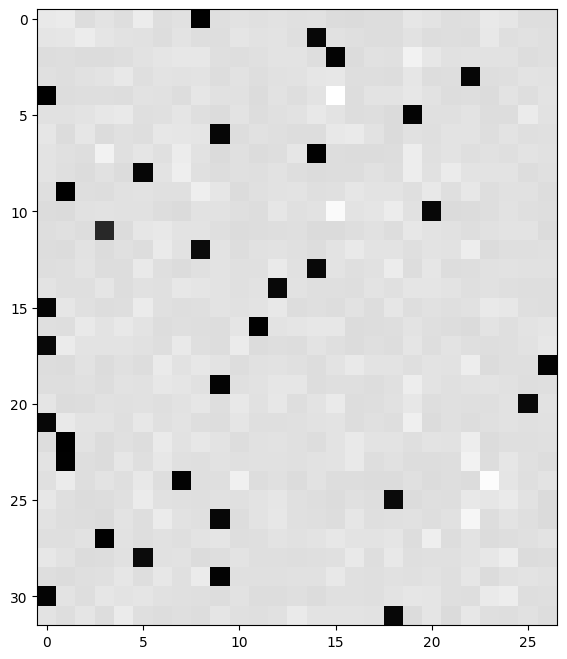

In [12]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray')


In [13]:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(dim=0, keepdim=True, correction=True) + 1e-5) + bnbias
print('max diff', (hpreact_fast - hpreact).abs().max())

max diff tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [14]:
dhprebn = bngain * bnvar_inv / n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [15]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [16]:
# Putting it all together
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g)

# Layer 1
W1 = torch.randn((n_embd*block_size, n_hidden),generator=g) * (5/3)/((n_embd * block_size)**0.5) # Kaiming (He) initilization
b1 = torch.randn(n_hidden,                      generator=g) * 0.1

# Layer 2
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.1
b2 = torch.randn(vocab_size,                    generator=g) * 0.1

# BatchNorm parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size
lossi = []

# use this context manager for efficiency once your backward pass is written
with torch.no_grad():
    # kick off optimization
    for i in range(max_steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

        # forward pass
        emb = C[Xb] # embed the characters into vectors
        Embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
        # Linear Layer
        hprebn = embcat @ W1 + b1 # hidden layer pre-activation
        # BatchNorm Layer
        #----------------------------------------------------
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, correction=True)
        bnvar_inv = (bnvar + 1e-5)**-0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        #----------------------------------------------------
        # Non-linearity
        h = torch.tanh(hpreact) # hidden layer
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Yb) # loss function

        # backward pass
        for p in parameters:
            p.grad = None
        # loss.backward()

        # manual backprop
        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n
        # 2nd layer backprop
        dh = dlogits @ W2.T
        dW2 = h.T @ dlogits
        db2 = dlogits.sum(0)
        # tanh
        dhpreact = (1.0 - h**2) * dh
        # batchnorm backprop
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = dhpreact.sum(0, keepdim=True)
        dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
        # 1st layer
        dembcat = dhprebn @ W1.T
        dW1 = embcat.T @ dhprebn
        db1 = dhprebn.sum(0)
        # embedding
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k,j]
                dC[ix] += demb[k,j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

        # update
        lr = 0.1 if i < 100000 else 0.01
        for p, grad in zip(parameters, grads):
            p.data += -lr * grad

        # track stats
        if i%10000 == 0:
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
            lossi.append(loss.log10().item())


12297
      0/ 200000: 3.6350
  10000/ 200000: 2.7294
  20000/ 200000: 2.8584
  30000/ 200000: 3.0932
  40000/ 200000: 3.0750
  50000/ 200000: 3.0942
  60000/ 200000: 2.8086
  70000/ 200000: 2.6684
  80000/ 200000: 2.6979
  90000/ 200000: 2.7929
 100000/ 200000: 2.5965
 110000/ 200000: 3.0879
 120000/ 200000: 2.8082
 130000/ 200000: 2.8609
 140000/ 200000: 2.8381
 150000/ 200000: 2.8359
 160000/ 200000: 2.8985
 170000/ 200000: 2.6623
 180000/ 200000: 2.7982
 190000/ 200000: 2.8340


In [17]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, correction=True)
    

In [18]:
@ torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
    h = torch.tanh(hpreact)
    logits = h@ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.822021484375
val 2.820218801498413


In [19]:
g= torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(emb.shape[0], -1)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
        h = torch.tanh(hpreact)
        logits = h@W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    # print(itos)
    print(''.join(itos[i] for i in out))

narmahxaae.
hlrihkimrs.
reaty.
hnaassnejr.
hnenfamesahc.
iaeei.
.
elmaia.
ceaiiv.
e.
lein.
h.
.
m.
.
oin.
eeijn.
s.
lilea.
.
